In [1]:
from pybaseball import playerid_lookup, statcast_pitcher

info = playerid_lookup("mize", "casey", fuzzy=True)
print(info[["name_first","name_last","key_mlbam"]])

Gathering player lookup table. This may take a moment.
  name_first name_last  key_mlbam
0      casey      mize     663554


In [2]:
from pybaseball import statcast_pitcher

bad_start = statcast_pitcher('2026-08-05', '2026-08-05', 663554)
season = statcast_pitcher('2026-03-01', '2026-08-09', 663554)

print("Bad start pitches:", bad_start.shape[0])
print("Season pitches:", season.shape[0])

Gathering Player Data
Gathering Player Data
Bad start pitches: 77
Season pitches: 1697


In [3]:
season_before = season[season['game_date'] != '2026-08-05']

print("Season pitch mix (excluding bad start):")
print(season_before['pitch_type'].value_counts())
print()
print("Bad start pitch mix:")
print(bad_start['pitch_type'].value_counts())

Season pitch mix (excluding bad start):
pitch_type
FF    559
SL    395
FS    383
SI    183
SV    100
Name: count, dtype: int64

Bad start pitch mix:
pitch_type
FF    24
SL    22
FS    18
SI     8
SV     5
Name: count, dtype: int64


In [4]:
print("Velocity comparison by pitch type:")
print("Season avg:")
print(season_before.groupby('pitch_type')['release_speed'].mean().round(1))
print()
print("Bad start avg:")
print(bad_start.groupby('pitch_type')['release_speed'].mean().round(1))


Velocity comparison by pitch type:
Season avg:
pitch_type
FF    93.5
FS    87.8
SI    93.6
SL    87.7
SV    81.7
Name: release_speed, dtype: float64

Bad start avg:
pitch_type
FF    93.4
FS    88.7
SI    94.1
SL    88.4
SV    81.7
Name: release_speed, dtype: float64


In [5]:
zone_before = season_before[season_before['zone'] <= 9]
zone_bad = bad_start[bad_start['zone'] <= 9]

print("Zone% (season before):", round(100*len(zone_before)/len(season_before),1))
print("Zone% (bad start):", round(100*len(zone_bad)/len(bad_start),1))
print()

contact_before = season_before[season_before['type']=='X']
contact_bad = bad_start[bad_start['type']=='X']

print("Balls in play, season avg exit velo:", round(contact_before['launch_speed'].mean(),1))
print("Balls in play, bad start avg exit velo:", round(contact_bad['launch_speed'].mean(),1))
print()
print("Hard hit% (95+) season:", round(100*(contact_before['launch_speed']>=95).sum()/len(contact_before),1))
print("Hard hit% (95+) bad start:", round(100*(contact_bad['launch_speed']>=95).sum()/len(contact_bad),1))

Zone% (season before): 49.5
Zone% (bad start): 48.1

Balls in play, season avg exit velo: 87.1
Balls in play, bad start avg exit velo: 93.8

Hard hit% (95+) season: 34.1
Hard hit% (95+) bad start: 61.1


In [6]:
print("Exit velo allowed by pitch type, season:")
print(contact_before.groupby('pitch_type')['launch_speed'].mean().round(1))
print()
print("Exit velo allowed by pitch type, bad start:")
print(contact_bad.groupby('pitch_type')['launch_speed'].mean().round(1))
print()
print("Average plate location (season before), by pitch type:")
print(season_before.groupby('pitch_type')[['plate_x','plate_z']].mean().round(2))
print()
print("Average plate location (bad start), by pitch type:")
print(bad_start.groupby('pitch_type')[['plate_x','plate_z']].mean().round(2))

Exit velo allowed by pitch type, season:
pitch_type
FF    90.0
FS    85.1
SI    87.5
SL    86.6
SV    83.3
Name: launch_speed, dtype: float64

Exit velo allowed by pitch type, bad start:
pitch_type
FF     93.5
FS     95.2
SI    101.7
SL     93.8
SV     82.2
Name: launch_speed, dtype: float64

Average plate location (season before), by pitch type:
            plate_x  plate_z
pitch_type                  
FF             0.02     2.79
FS            -0.21     1.58
SI            -0.30     2.51
SL             0.07     2.33
SV             0.46     1.61

Average plate location (bad start), by pitch type:
            plate_x  plate_z
pitch_type                  
FF             0.22     2.67
FS            -0.11     1.61
SI            -0.42     2.65
SL             0.69     1.77
SV             0.90     1.19


In [7]:
print("Splitter movement, season before:")
print(season_before[season_before['pitch_type']=='FS'][['pfx_x','pfx_z','release_spin_rate']].mean().round(2))
print()
print("Splitter movement, bad start:")
print(bad_start[bad_start['pitch_type']=='FS'][['pfx_x','pfx_z','release_spin_rate']].mean().round(2))

Splitter movement, season before:
pfx_x                  -1.23
pfx_z                   0.44
release_spin_rate    1497.14
dtype: float64

Splitter movement, bad start:
pfx_x                  -1.11
pfx_z                   0.51
release_spin_rate    1501.28
dtype: float64


In [8]:
from pybaseball import statcast_pitcher

mize_2024 = statcast_pitcher('2024-03-01', '2024-11-01', 663554)
mize_2025 = statcast_pitcher('2025-03-01', '2025-11-01', 663554)
mize_2026 = statcast_pitcher('2026-03-01', '2026-08-09', 663554)

for year, df in [('2024', mize_2024), ('2025', mize_2025), ('2026', mize_2026)]:
    sl = df[df['pitch_type']=='SL']
    print(year, "slider pitches:", len(sl))
    print(sl[['release_speed','pfx_x','pfx_z','release_spin_rate','spin_axis']].mean().round(2))
    print()

Gathering Player Data
Gathering Player Data
Gathering Player Data
2024 slider pitches: 506
release_speed          85.84
pfx_x                   0.30
pfx_z                   0.03
release_spin_rate    2231.07
spin_axis             106.62
dtype: float64

2025 slider pitches: 442
release_speed          88.17
pfx_x                   0.19
pfx_z                   0.38
release_spin_rate    2186.24
spin_axis             167.89
dtype: float64

2026 slider pitches: 417
release_speed          87.77
pfx_x                   0.30
pfx_z                   0.43
release_spin_rate    2230.09
spin_axis             172.70
dtype: float64



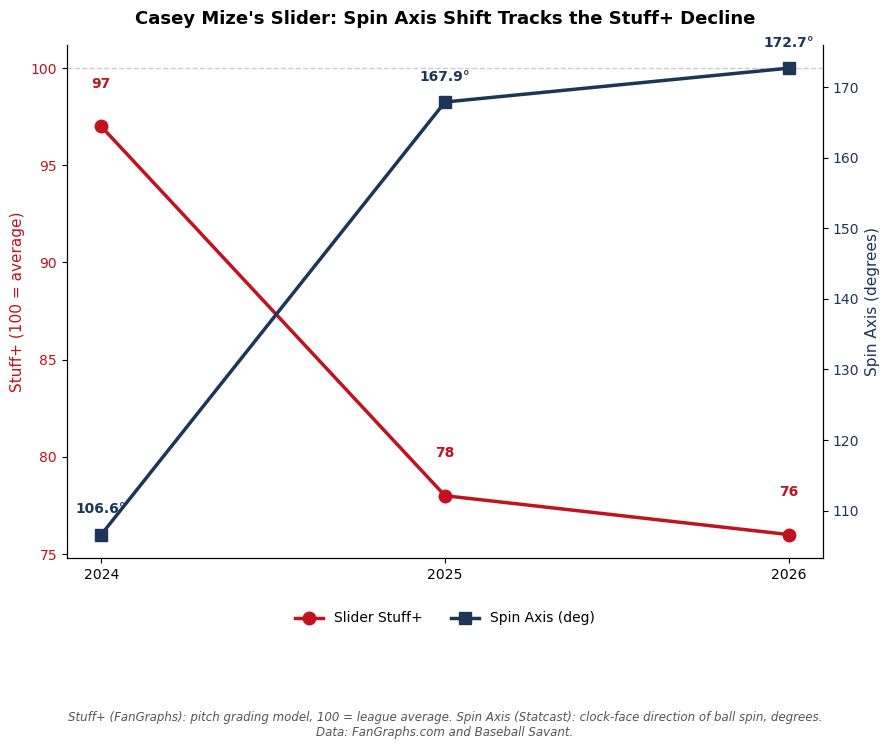

In [9]:
import matplotlib.pyplot as plt

years = ['2024', '2025', '2026']
stuff_plus = [97, 78, 76]
spin_axis = [106.6, 167.9, 172.7]

blue = "#1d3557"
red = "#c1121f"

fig, ax1 = plt.subplots(figsize=(9, 6.5))
fig.patch.set_facecolor("white")

ax1.plot(years, stuff_plus, marker='o', color=red, linewidth=2.5, markersize=9, label="Slider Stuff+")
ax1.set_ylabel("Stuff+ (100 = average)", fontsize=11, color=red)
ax1.tick_params(axis='y', labelcolor=red)
ax1.axhline(100, color="#cccccc", linewidth=1, linestyle="--")
for x, y in zip(years, stuff_plus):
    ax1.text(x, y + 2, str(y), ha='center', fontsize=10, fontweight='bold', color=red)

ax2 = ax1.twinx()
ax2.plot(years, spin_axis, marker='s', color=blue, linewidth=2.5, markersize=9, label="Spin Axis (deg)")
ax2.set_ylabel("Spin Axis (degrees)", fontsize=11, color=blue)
ax2.tick_params(axis='y', labelcolor=blue)
for x, y in zip(years, spin_axis):
    ax2.text(x, y + 3, f"{y}°", ha='center', fontsize=10, fontweight='bold', color=blue)

ax1.set_title("Casey Mize's Slider: Spin Axis Shift Tracks the Stuff+ Decline", fontsize=13, fontweight="bold", pad=15)
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.08))

fig.text(0.5, -0.14, "Stuff+ (FanGraphs): pitch grading model, 100 = league average. Spin Axis (Statcast): clock-face direction of ball spin, degrees.\nData: FanGraphs.com and Baseball Savant.",
          ha="center", fontsize=8.5, style="italic", color="#555555")

plt.tight_layout()
plt.savefig("mize_slider_spin.png", dpi=200, bbox_inches="tight")
plt.show()

In [10]:
sinker = season[season['pitch_type']=='SI'].copy()
sinker_bip = sinker[sinker['type']=='X']

low = sinker_bip[sinker_bip['plate_z'] < 2.2]
high = sinker_bip[sinker_bip['plate_z'] >= 2.2]

print("Sinker located low (plate_z < 2.2):")
print("  Count:", len(low))
print("  Avg exit velo:", round(low['launch_speed'].mean(),1))
print("  Hard hit%:", round(100*(low['launch_speed']>=95).sum()/len(low),1) if len(low)>0 else "n/a")

print()
print("Sinker located high (plate_z >= 2.2):")
print("  Count:", len(high))
print("  Avg exit velo:", round(high['launch_speed'].mean(),1))
print("  Hard hit%:", round(100*(high['launch_speed']>=95).sum()/len(high),1) if len(high)>0 else "n/a")

Sinker located low (plate_z < 2.2):
  Count: 20
  Avg exit velo: 91.3
  Hard hit%: 40.0

Sinker located high (plate_z >= 2.2):
  Count: 27
  Avg exit velo: 85.7
  Hard hit%: 25.9


In [11]:
inside = sinker_bip[sinker_bip['plate_x'] < -0.3]
outside = sinker_bip[sinker_bip['plate_x'] >= -0.3]

print("Sinker located arm-side/in (plate_x < -0.3):")
print("  Count:", len(inside))
print("  Avg exit velo:", round(inside['launch_speed'].mean(),1))
print("  Hard hit%:", round(100*(inside['launch_speed']>=95).sum()/len(inside),1) if len(inside)>0 else "n/a")

print()
print("Sinker located away/other side (plate_x >= -0.3):")
print("  Count:", len(outside))
print("  Avg exit velo:", round(outside['launch_speed'].mean(),1))
print("  Hard hit%:", round(100*(outside['launch_speed']>=95).sum()/len(outside),1) if len(outside)>0 else "n/a")

Sinker located arm-side/in (plate_x < -0.3):
  Count: 25
  Avg exit velo: 83.9
  Hard hit%: 24.0

Sinker located away/other side (plate_x >= -0.3):
  Count: 22
  Avg exit velo: 92.9
  Hard hit%: 40.9


In [12]:
bad_sinker = bad_start[bad_start['pitch_type']=='SI']
print("Bad start sinker locations (plate_x):")
print(bad_sinker[['plate_x','plate_z']])
print()
print("Bad start sinker avg plate_x:", round(bad_sinker['plate_x'].mean(),2))
print("Season sinker avg plate_x (all pitches, not just BIP):", round(sinker['plate_x'].mean(),2))

Bad start sinker locations (plate_x):
     plate_x   plate_z
1   0.311445  2.857429
5  -0.174839  2.177792
16 -0.637638  3.077974
47 -0.425192  2.342370
51 -0.353200  3.605658
52 -0.431873  2.898927
62 -0.502987  2.195200
63 -1.163278  2.053155

Bad start sinker avg plate_x: -0.42
Season sinker avg plate_x (all pitches, not just BIP): -0.3


In [13]:
slurve = season[season['pitch_type']=='CS'].copy()
if len(slurve) == 0:
    slurve = season[season['pitch_type']=='SV'].copy()

print("Slurve pitches:", len(slurve))
print(slurve['pitch_type'].unique())
print()
print("By batter handedness:")
print(slurve.groupby('stand').size())
print()

slurve_swings = slurve[slurve['description'].isin(['swinging_strike','swinging_strike_blocked','foul','foul_tip','hit_into_play'])]
slurve_whiffs = slurve[slurve['description'].isin(['swinging_strike','swinging_strike_blocked'])]

for hand in ['L', 'R']:
    sub = slurve[slurve['stand']==hand]
    sub_swings = slurve_swings[slurve_swings['stand']==hand]
    sub_whiffs = slurve_whiffs[slurve_whiffs['stand']==hand]
    if len(sub) > 0:
        print(f"vs {hand}HB: {len(sub)} pitches, whiff rate: {round(100*len(sub_whiffs)/len(sub_swings),1) if len(sub_swings)>0 else 'n/a'}%")

Slurve pitches: 105
['SV']

By batter handedness:
stand
L    23
R    82
dtype: int64

vs LHB: 23 pitches, whiff rate: 14.3%
vs RHB: 82 pitches, whiff rate: 21.9%


In [14]:
rhb = season[season['stand']=='R']
print("Pitch mix vs RHB (season):")
print((rhb['pitch_type'].value_counts(normalize=True) * 100).round(1))


Pitch mix vs RHB (season):
pitch_type
SI    25.7
FF    24.9
SL    23.0
FS    15.4
SV    11.1
Name: proportion, dtype: float64


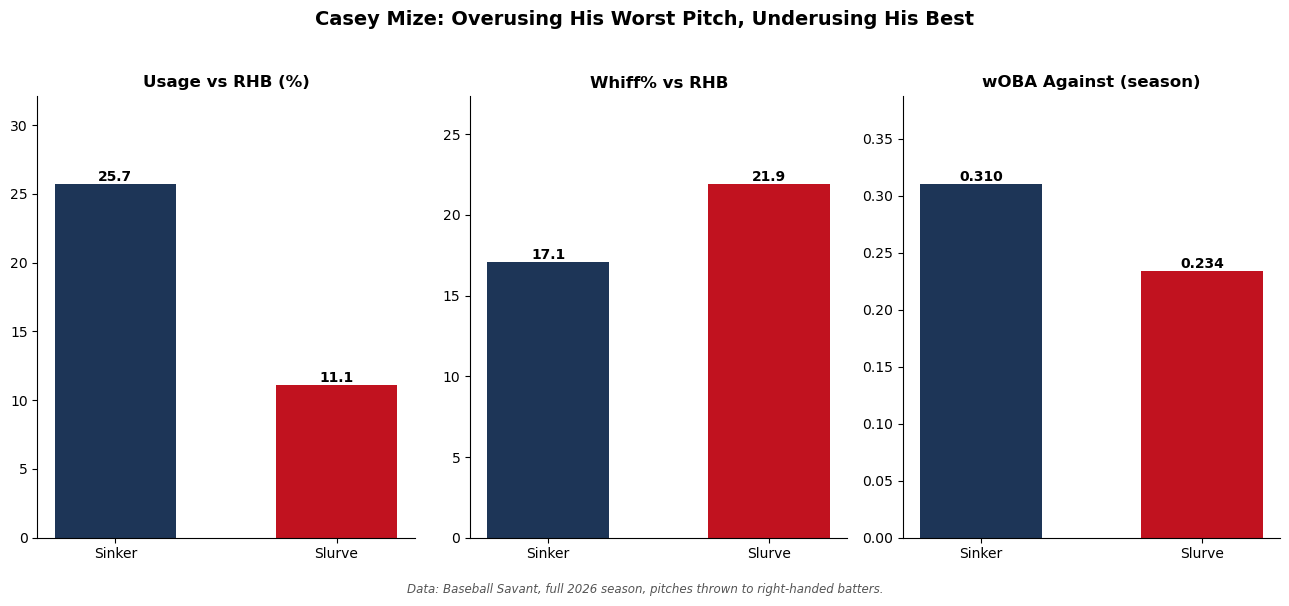

In [15]:
import matplotlib.pyplot as plt

pitches = ['Sinker', 'Slurve']
usage = [25.7, 11.1]
whiff = [17.1, 21.9]
woba = [.310, .234]

blue = "#1d3557"
red = "#c1121f"

fig, axes = plt.subplots(1, 3, figsize=(13, 5.5))
fig.patch.set_facecolor("white")

titles = ["Usage vs RHB (%)", "Whiff% vs RHB", "wOBA Against (season)"]
data = [usage, whiff, woba]

for ax, title, vals in zip(axes, titles, data):
    bars = ax.bar(pitches, vals, color=[blue, red], width=0.55)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fmt = "{:.3f}" if max(vals) < 1 else "{:.1f}"
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), fmt.format(val), ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.25)

fig.suptitle("Casey Mize: Overusing His Worst Pitch, Underusing His Best", fontsize=14, fontweight="bold", y=1.03)
fig.text(0.5, -0.03, "Data: Baseball Savant, full 2026 season, pitches thrown to right-handed batters.",
          ha="center", fontsize=8.5, style="italic", color="#555555")

plt.tight_layout()
plt.savefig("mize_usage_gap.png", dpi=200, bbox_inches="tight")
plt.show()

In [16]:
print("Full season pitch mix (all batters):")
print((season['pitch_type'].value_counts(normalize=True) * 100).round(1))
print()

for pitch in season['pitch_type'].unique():
    sub = season[season['pitch_type']==pitch]
    sub_bip = sub[sub['type']=='X']
    sub_swings = sub[sub['description'].isin(['swinging_strike','swinging_strike_blocked','foul','foul_tip','hit_into_play'])]
    sub_whiffs = sub[sub['description'].isin(['swinging_strike','swinging_strike_blocked'])]
    whiff_pct = round(100*len(sub_whiffs)/len(sub_swings),1) if len(sub_swings)>0 else None
    print(pitch, "- pitches:", len(sub), "| whiff%:", whiff_pct)

Full season pitch mix (all batters):
pitch_type
FF    34.4
SL    24.6
FS    23.6
SI    11.3
SV     6.2
Name: proportion, dtype: float64

FF - pitches: 583 | whiff%: 18.9
SI - pitches: 191 | whiff%: 14.7
SL - pitches: 417 | whiff%: 24.9
FS - pitches: 401 | whiff%: 32.0
SV - pitches: 105 | whiff%: 20.5


In [17]:
for pitch in season['pitch_type'].unique():
    sub = season[season['pitch_type']==pitch]
    sub_bip = sub[sub['type']=='X']
    print(pitch, "- xwOBA against:", round(sub_bip['estimated_woba_using_speedangle'].mean(),3) if len(sub_bip)>0 else "n/a")
    

FF - xwOBA against: 0.286
SI - xwOBA against: 0.353
SL - xwOBA against: 0.367
FS - xwOBA against: 0.366
SV - xwOBA against: 0.37


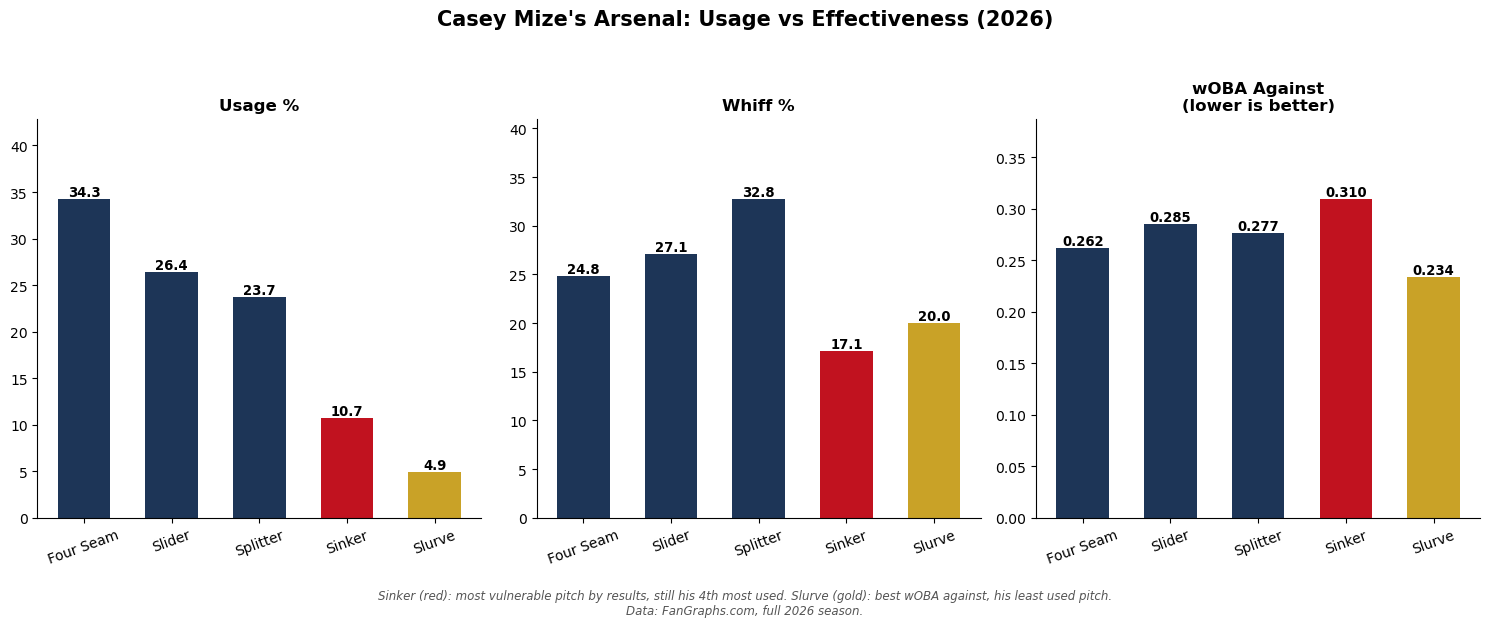

In [18]:
import matplotlib.pyplot as plt

pitches = ['Four Seam', 'Slider', 'Splitter', 'Sinker', 'Slurve']
usage = [34.3, 26.4, 23.7, 10.7, 4.9]
whiff = [24.8, 27.1, 32.8, 17.1, 20.0]
woba = [.262, .285, .277, .310, .234]

blue = "#1d3557"
red = "#c1121f"
gold = "#c9a227"

colors = [blue, blue, blue, red, gold]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.patch.set_facecolor("white")

titles = ["Usage %", "Whiff %", "wOBA Against\n(lower is better)"]
data = [usage, whiff, woba]

for ax, title, vals in zip(axes, titles, data):
    bars = ax.bar(pitches, vals, color=colors, width=0.6)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis='x', rotation=20)
    fmt = "{:.3f}" if max(vals) < 1 else "{:.1f}"
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), fmt.format(val), ha="center", va="bottom", fontsize=9.5, fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.25)

fig.suptitle("Casey Mize's Arsenal: Usage vs Effectiveness (2026)", fontsize=15, fontweight="bold", y=1.04)
fig.text(0.5, -0.06,
    "Sinker (red): most vulnerable pitch by results, still his 4th most used. Slurve (gold): best wOBA against, his least used pitch.\n"
    "Data: FanGraphs.com, full 2026 season.",
    ha="center", fontsize=8.5, style="italic", color="#555555")

plt.tight_layout()
plt.savefig("mize_full_arsenal.png", dpi=200, bbox_inches="tight")
plt.show()

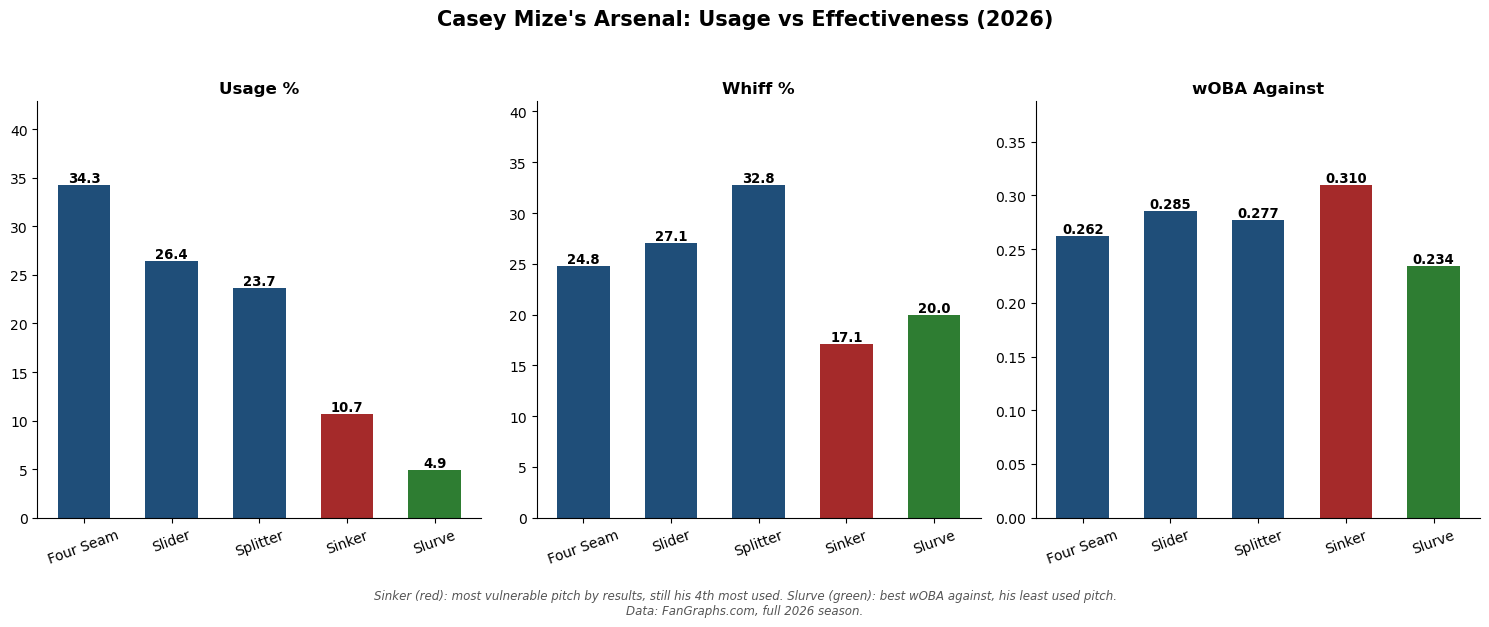

In [19]:
import matplotlib.pyplot as plt

pitches = ['Four Seam', 'Slider', 'Splitter', 'Sinker', 'Slurve']
usage = [34.3, 26.4, 23.7, 10.7, 4.9]
whiff = [24.8, 27.1, 32.8, 17.1, 20.0]
woba = [.262, .285, .277, .310, .234]

navy = "#1f4e79"
crimson = "#a52a2a"
green = "#2e7d32"

colors = [navy, navy, navy, crimson, green]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.patch.set_facecolor("white")

titles = ["Usage %", "Whiff %", "wOBA Against"]
data = [usage, whiff, woba]

for ax, title, vals in zip(axes, titles, data):
    bars = ax.bar(pitches, vals, color=colors, width=0.6)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis='x', rotation=20)
    fmt = "{:.3f}" if max(vals) < 1 else "{:.1f}"
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), fmt.format(val), ha="center", va="bottom", fontsize=9.5, fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.25)

fig.suptitle("Casey Mize's Arsenal: Usage vs Effectiveness (2026)", fontsize=15, fontweight="bold", y=1.04)
fig.text(0.5, -0.06,
    "Sinker (red): most vulnerable pitch by results, still his 4th most used. Slurve (green): best wOBA against, his least used pitch.\n"
    "Data: FanGraphs.com, full 2026 season.",
    ha="center", fontsize=8.5, style="italic", color="#555555")

plt.tight_layout()
plt.savefig("mize_full_arsenal.png", dpi=200, bbox_inches="tight")
plt.show()

In [20]:
bad_start_sorted = bad_start.sort_values(['at_bat_number', 'pitch_number']).reset_index(drop=True)
bad_start_sorted['prev_pitch'] = bad_start_sorted.groupby('at_bat_number')['pitch_type'].shift(1)

hard_hit = bad_start_sorted[(bad_start_sorted['type']=='X') & (bad_start_sorted['launch_speed']>=95)]

print("Hard hit balls and what preceded them:")
print(hard_hit[['at_bat_number','pitch_number','pitch_type','prev_pitch','launch_speed','description']])
print()

same_pitch_repeat = bad_start_sorted[bad_start_sorted['pitch_type'] == bad_start_sorted['prev_pitch']]
print("Back-to-back same pitch type count:", len(same_pitch_repeat))
print("Total pitches with a previous pitch in same AB:", bad_start_sorted['prev_pitch'].notna().sum())

Hard hit balls and what preceded them:
    at_bat_number  pitch_number pitch_type prev_pitch  launch_speed  \
7               5             2         FS         FF         101.7   
9               6             2         FF         SL          95.9   
18              8             3         FS         SL         104.7   
23             14             3         FF         FF          98.6   
29             16             3         SI         FF          98.9   
31             17             2         FF         SL          97.2   
52             25             4         FS         FF         105.8   
55             26             3         SV         SL          98.0   
60             31             2         SI         SL         104.5   
65             32             5         SL         SL         104.4   
68             34             1         SL        NaN          99.9   

      description  
7   hit_into_play  
9   hit_into_play  
18  hit_into_play  
23  hit_into_play  
29  hit_

In [21]:
season_sorted = season_before.sort_values(['game_date','at_bat_number','pitch_number']).reset_index(drop=True)
season_sorted['prev_pitch'] = season_sorted.groupby(['game_date','at_bat_number'])['pitch_type'].shift(1)

season_repeat = season_sorted[season_sorted['pitch_type'] == season_sorted['prev_pitch']]
season_total_with_prev = season_sorted['prev_pitch'].notna().sum()

print("Season same-pitch-repeat rate:", round(100*len(season_repeat)/season_total_with_prev,1), "%")
print("Bad start same-pitch-repeat rate:", round(100*21/55,1), "%")

Season same-pitch-repeat rate: 27.4 %
Bad start same-pitch-repeat rate: 38.2 %


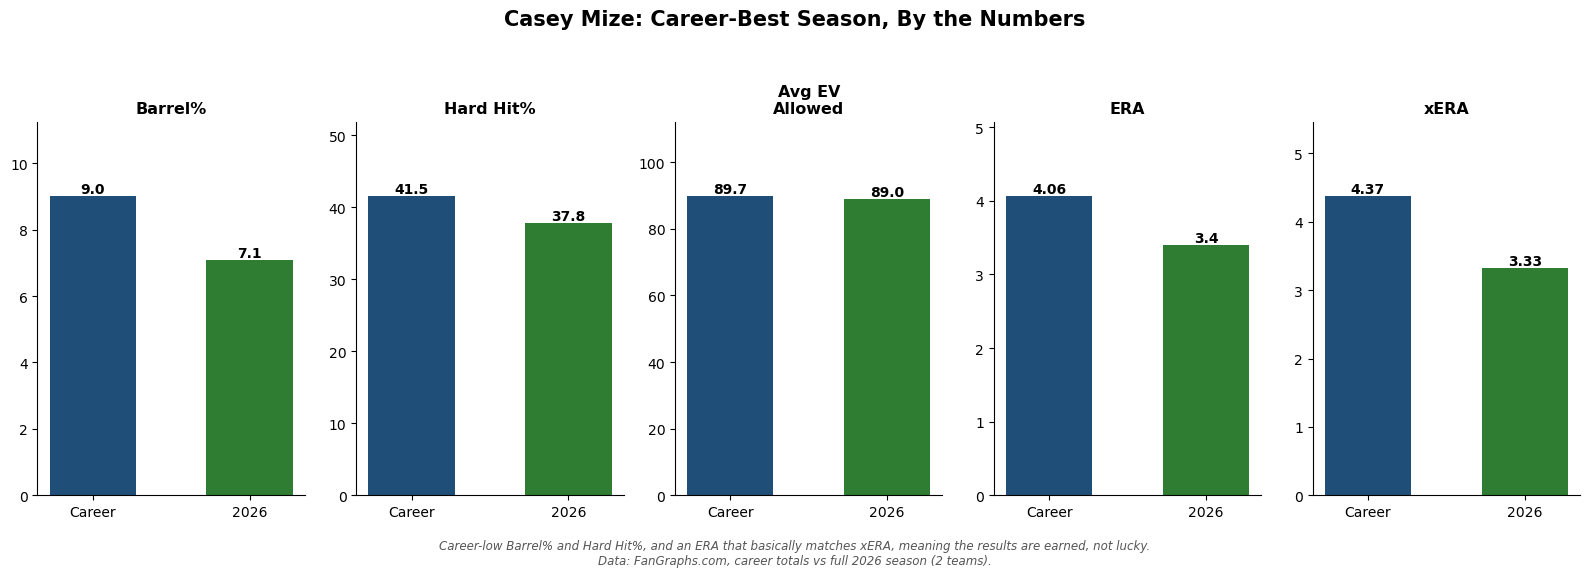

In [22]:
import matplotlib.pyplot as plt

labels = ["Barrel%", "Hard Hit%", "Avg EV\nAllowed", "ERA", "xERA"]
career = [9.0, 41.5, 89.7, 4.06, 4.37]
this_year = [7.1, 37.8, 89.0, 3.40, 3.33]

navy = "#1f4e79"
green = "#2e7d32"

fig, axes = plt.subplots(1, 5, figsize=(16, 5))
fig.patch.set_facecolor("white")

for i, (label, c, y) in enumerate(zip(labels, career, this_year)):
    ax = axes[i]
    bars = ax.bar(["Career", "2026"], [c, y], color=[navy, green], width=0.55)
    ax.set_title(label, fontsize=11.5, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for bar, val in zip(bars, [c, y]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_ylim(0, max(c, y) * 1.25)

fig.suptitle("Casey Mize: Career-Best Season, By the Numbers", fontsize=15, fontweight="bold", y=1.05)
fig.text(0.5, -0.06,
    "Career-low Barrel% and Hard Hit%, and an ERA that basically matches xERA, meaning the results are earned, not lucky.\n"
    "Data: FanGraphs.com, career totals vs full 2026 season (2 teams).",
    ha="center", fontsize=8.5, style="italic", color="#555555")

plt.tight_layout()
plt.savefig("mize_good_signs.png", dpi=200, bbox_inches="tight")
plt.show()

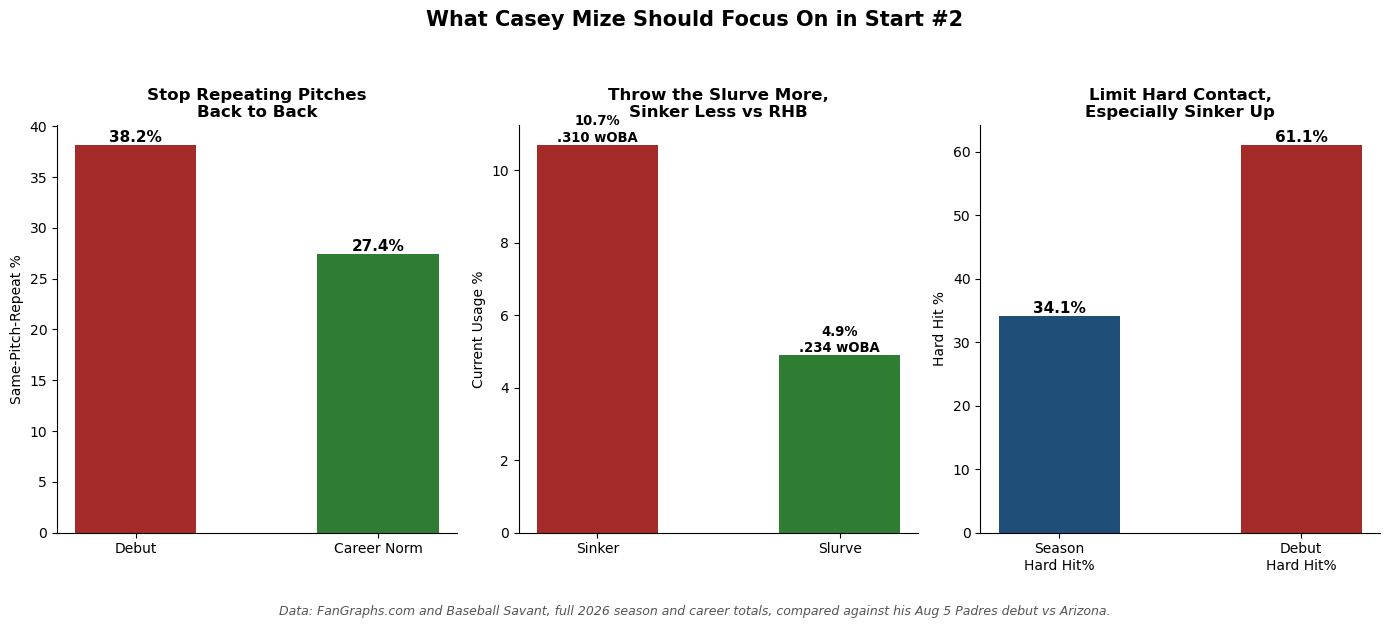

In [26]:
import matplotlib.pyplot as plt

navy = "#1f4e79"
crimson = "#a52a2a"
green = "#2e7d32"

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5))
fig.patch.set_facecolor("white")

ax1 = axes[0]
labels1 = ["Debut", "Career Norm"]
vals1 = [38.2, 27.4]
bars1 = ax1.bar(labels1, vals1, color=[crimson, green], width=0.5)
ax1.set_title("Stop Repeating Pitches\nBack to Back", fontsize=12, fontweight="bold")
ax1.set_ylabel("Same-Pitch-Repeat %")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
for bar, val in zip(bars1, vals1):
    ax1.text(bar.get_x()+bar.get_width()/2, val, f"{val}%", ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2 = axes[1]
pitches2 = ['Sinker', 'Slurve']
usage2 = [10.7, 4.9]
bars2 = ax2.bar(pitches2, usage2, color=[crimson, green], width=0.5)
ax2.set_title("Throw the Slurve More,\nSinker Less vs RHB", fontsize=12, fontweight="bold")
ax2.set_ylabel("Current Usage %")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
for bar, val, w in zip(bars2, usage2, [".310 wOBA", ".234 wOBA"]):
    ax2.text(bar.get_x()+bar.get_width()/2, val, f"{val}%\n{w}", ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax3 = axes[2]
labels3 = ["Season\nHard Hit%", "Debut\nHard Hit%"]
vals3 = [34.1, 61.1]
bars3 = ax3.bar(labels3, vals3, color=[navy, crimson], width=0.5)
ax3.set_title("Limit Hard Contact,\nEspecially Sinker Up", fontsize=12, fontweight="bold")
ax3.set_ylabel("Hard Hit %")
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
for bar, val in zip(bars3, vals3):
    ax3.text(bar.get_x()+bar.get_width()/2, val, f"{val}%", ha='center', va='bottom', fontsize=11, fontweight='bold')

fig.suptitle("What Casey Mize Should Focus On in Start #2", fontsize=15, fontweight="bold", y=1.05)
fig.text(0.5, -0.05,
    "Data: FanGraphs.com and Baseball Savant, full 2026 season and career totals, compared against his Aug 5 Padres debut vs Arizona.",
    ha="center", fontsize=9, style="italic", color="#555555")

plt.tight_layout()
plt.savefig("mize_start2_focus2.png", dpi=200, bbox_inches="tight")
plt.show()

In [28]:
season_before = season_before.copy()

print("Debut zone breakdown:")
print((bad_start['location_zone'].value_counts(normalize=True) * 100).round(1))
print()
print("Season zone breakdown:")
print((season_before['location_zone'].value_counts(normalize=True) * 100).round(1))
print()

hard_hit_bad = bad_start[(bad_start['type']=='X') & (bad_start['launch_speed']>=95)]
print("Zone location of the 11 hard-hit balls:")
print(hard_hit_bad[['pitch_type','plate_x','plate_z','location_zone','launch_speed']])

Debut zone breakdown:
location_zone
chase/waste    50.6
heart          24.7
shadow/edge    24.7
Name: proportion, dtype: float64

Season zone breakdown:
location_zone
chase/waste    48.5
heart          31.3
shadow/edge    20.2
Name: proportion, dtype: float64

Zone location of the 11 hard-hit balls:
   pitch_type   plate_x   plate_z location_zone  launch_speed
8          SL  0.660132  1.411796   chase/waste          99.9
11         SL  0.044074  1.982520         heart         104.4
16         SI -0.637638  3.077974   shadow/edge         104.5
21         SV  0.011065  1.866139         heart          98.0
24         FS -0.262932  2.688960         heart         105.8
45         FF -0.455984  3.139491         heart          97.2
47         SI -0.425192  2.342370         heart          98.9
53         FF -0.092981  2.708359         heart          98.6
58         FS -0.581107  1.888408   shadow/edge         104.7
67         FF  0.515805  2.798531         heart          95.9
69         FS  0.

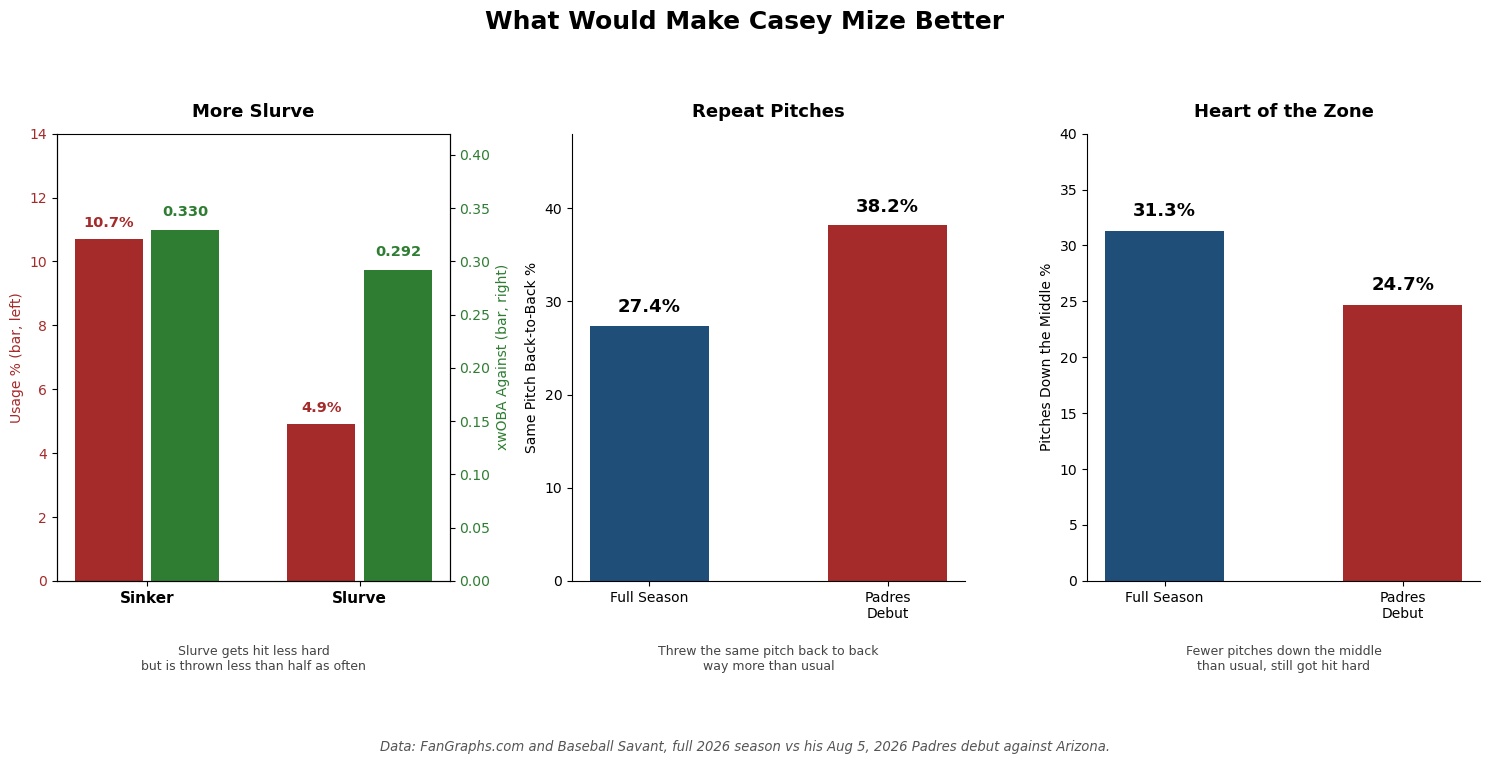

In [34]:
import matplotlib.pyplot as plt

navy = "#1f4e79"
crimson = "#a52a2a"
green = "#2e7d32"

fig, axes = plt.subplots(1, 3, figsize=(15, 6.5))
fig.patch.set_facecolor("white")

ax1 = axes[0]
pitches = ['Sinker', 'Slurve']
usage = [10.7, 4.9]
xwoba = [.330, .292]
x = range(2)
width = 0.32
bars1a = ax1.bar([i - width/2 - 0.02 for i in x], usage, width, color=crimson, label="Usage %")
ax1b = ax1.twinx()
bars1b = ax1b.bar([i + width/2 + 0.02 for i in x], xwoba, width, color=green, label="xwOBA Against")
ax1.set_xticks(list(x))
ax1.set_xticklabels(pitches, fontsize=11, fontweight='bold')
ax1.set_title("More Slurve", fontsize=13, fontweight="bold", pad=12)
ax1.set_ylabel("Usage % (bar, left)", fontsize=10, color=crimson)
ax1b.set_ylabel("xwOBA Against (bar, right)", fontsize=10, color=green)
ax1.tick_params(axis='y', labelcolor=crimson)
ax1b.tick_params(axis='y', labelcolor=green)
ax1.spines["top"].set_visible(False)
ax1.set_ylim(0, 14)
ax1b.set_ylim(0, 0.42)
for bar, val in zip(bars1a, usage):
    ax1.text(bar.get_x()+bar.get_width()/2, val+0.3, f"{val}%", ha='center', va='bottom', fontsize=10.5, fontweight='bold', color=crimson)
for bar, val in zip(bars1b, xwoba):
    ax1b.text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.3f}", ha='center', va='bottom', fontsize=10.5, fontweight='bold', color=green)
ax1.text(0.5, -0.2, "Slurve gets hit less hard\nbut is thrown less than half as often", transform=ax1.transAxes, ha='center', fontsize=9, color="#444444")

ax2 = axes[1]
labels2 = ["Full Season", "Padres\nDebut"]
vals2 = [27.4, 38.2]
bars2 = ax2.bar(labels2, vals2, color=[navy, crimson], width=0.5)
ax2.set_title("Repeat Pitches", fontsize=13, fontweight="bold", pad=12)
ax2.set_ylabel("Same Pitch Back-to-Back %", fontsize=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.set_ylim(0, 48)
for bar, val in zip(bars2, vals2):
    ax2.text(bar.get_x()+bar.get_width()/2, val+1, f"{val}%", ha='center', va='bottom', fontsize=13, fontweight='bold')
ax2.text(0.5, -0.2, "Threw the same pitch back to back\nway more than usual", transform=ax2.transAxes, ha='center', fontsize=9, color="#444444")

ax3 = axes[2]
labels3 = ["Full Season", "Padres\nDebut"]
vals3 = [31.3, 24.7]
bars3 = ax3.bar(labels3, vals3, color=[navy, crimson], width=0.5)
ax3.set_title("Heart of the Zone", fontsize=13, fontweight="bold", pad=12)
ax3.set_ylabel("Pitches Down the Middle %", fontsize=10)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.set_ylim(0, 40)
for bar, val in zip(bars3, vals3):
    ax3.text(bar.get_x()+bar.get_width()/2, val+1, f"{val}%", ha='center', va='bottom', fontsize=13, fontweight='bold')
ax3.text(0.5, -0.2, "Fewer pitches down the middle\nthan usual, still got hit hard", transform=ax3.transAxes, ha='center', fontsize=9, color="#444444")

fig.suptitle("What Would Make Casey Mize Better", fontsize=18, fontweight="bold", y=1.06)
fig.text(0.5, -0.08, "Data: FanGraphs.com and Baseball Savant, full 2026 season vs his Aug 5, 2026 Padres debut against Arizona.",
          ha="center", fontsize=9.5, style="italic", color="#555555")

plt.tight_layout()
plt.savefig("mize_focus_v5.png", dpi=200, bbox_inches="tight")
plt.show()